In [1]:
%matplotlib widget
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from simulate.module import Module
from simulations import dcir

logger = logging.getLogger(__name__)

In [2]:
kinds: dict = {
    "Open-circuit voltage / V": "lut",
    "R0 / Ohm": "spline",
    "R1 / Ohm": "spline",
    "R2 / Ohm": "spline",
    "Tau1 / s": "constant",
    "Tau2 / s": "constant",
}
options: dict = {
    "Open-circuit voltage / V": {"kind": "quadratic"},
    "R0 / Ohm": {"k": 2, "n": 5},
    "R1 / Ohm": {"k": 2, "n": 5},
    "R2 / Ohm": {"k": 2, "n": 5},
    "Tau1 / s": None,
    "Tau2 / s": None,
}

module = Module(
    n_parallel=12,
    n_series=4,
    cell_parameters={
        "Std SOH / %": 2,
        "Std SOR / %": 7,
        "Nominal capacity / Ah": 5.0,
        "Initial SOC / %": 50,
    },
    number_of_rc_elements=2,
    bussbar_parameters={
        "Positive terminal relative width / 1": 10,
        "Negative terminal relative width / 1": 10,
        "Mean series resistance / Ohm": 1e-3,
        "Std series resistance / Ohm": 1e-4,
        "Mean parallel resistance / Ohm": 1e-4,
        "Std parallel resistance / Ohm": 1e-5,
    },
    interpolants=kinds,
    interpolants_options=options,
)

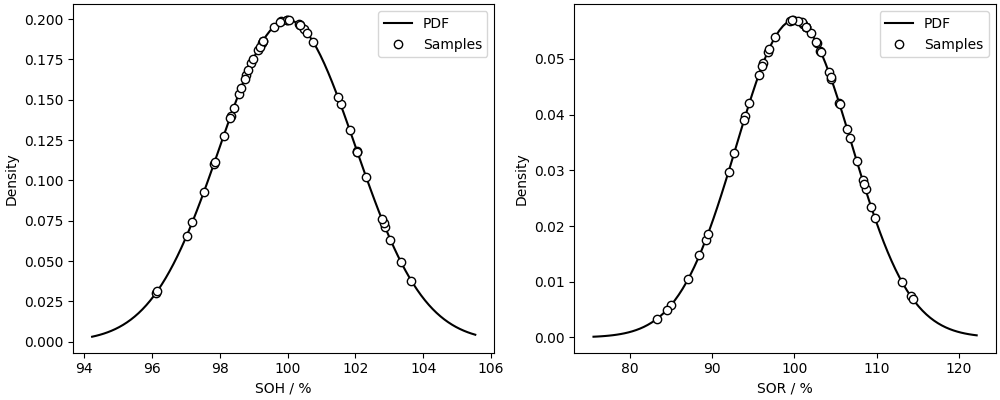

In [3]:
def pde(x, mu, sigma):
    return 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


fig, axs = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

vals = [
    module.cellgrid.SOH.flatten() * 100,
    module.cellgrid.SOR.flatten() * 100,
]
mu = [
    module.cellgrid.parameters["Mean SOH / %"],
    module.cellgrid.parameters["Mean SOR / %"],
]
sigma = [
    module.cellgrid.parameters["Std SOH / %"],
    module.cellgrid.parameters["Std SOR / %"],
]
names = ["SOH / %", "SOR / %"]
for i, (x, m, s) in enumerate(zip(vals, mu, sigma)):
    rng = (x.max() - x.min()) * 0.25
    z = np.linspace(x.min() - rng, x.max() + rng, 100)
    axs[i].plot(z, pde(z, m, s), ls="-", color="k", label="PDF")
    axs[i].plot(
        x, pde(x, m, s), ls="none", marker="o", color="k", mfc="w", label="Samples"
    )
    axs[i].set_xlabel(names[i])
    axs[i].set_ylabel("Density")
    axs[i].legend(loc="upper right")

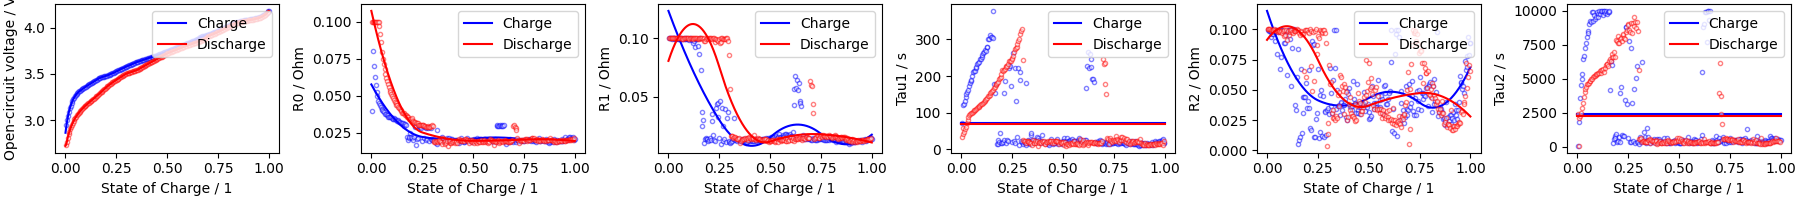

In [4]:
keys = list(module.cellgrid.interpolators.keys())
colors = {"Charge": "blue", "Discharge": "red"}

fig, axs = plt.subplots(
    1, len(keys), figsize=(3 * len(keys), 2), constrained_layout=True
)
soc = np.linspace(0, 1, 1000)

for i, key in enumerate(keys):
    for mode, interp in module.cellgrid.interpolators[key].items():
        axs[i].plot(
            interp._x,
            interp._y,
            ls="none",
            marker=".",
            color=colors[mode],
            mfc="w",
            alpha=0.5,
        )
        axs[i].plot(soc, interp(soc), label=mode, color=colors[mode])
    axs[i].set_xlabel("State of Charge / 1")
    axs[i].set_ylabel(key)
    axs[i].legend(loc="upper right")


In [3]:
logging.basicConfig(level=logging.DEBUG)
sim = dcir(module, newton_options={"sparse": True, "tol": 1e-1})

DEBUG:simulate.solver:Running newton's method with tol=0.1, maxiter=10, eps=None, sparse=True
DEBUG:simulate.solver:Iteration 0: norm of residual = 25.85503830431293
DEBUG:simulate.solver:Finished newton's method after 1 iterations with residual 4.379141262726286e-14


Integrating:   0%|          | 0/429 [00:00<?, ?step/s]

DEBUG:simulate.solver:Solving DAE with calc_ic=False
DEBUG:simulate.solver:Running newton's method with tol=0.1, maxiter=10, eps=None, sparse=True
DEBUG:simulate.solver:Finished newton's method after 0 iterations with residual 4.382742592843072e-14
DEBUG:simulate.solver:Solving DAE with calc_ic=False
DEBUG:simulate.solver:Running newton's method with tol=0.1, maxiter=10, eps=None, sparse=True
DEBUG:simulate.solver:Finished newton's method after 0 iterations with residual 4.383417512844284e-14
DEBUG:simulate.solver:Solving DAE with calc_ic=False
DEBUG:simulate.solver:Running newton's method with tol=0.1, maxiter=10, eps=None, sparse=True
DEBUG:simulate.solver:Finished newton's method after 0 iterations with residual 4.3782404673407054e-14
DEBUG:simulate.solver:Solving DAE with calc_ic=False
DEBUG:simulate.solver:Running newton's method with tol=0.1, maxiter=10, eps=None, sparse=True
DEBUG:simulate.solver:Finished newton's method after 0 iterations with residual 4.3942021346925415e-14
DE

In [17]:
np.array(sim.y).shape

(430, 4, 12)

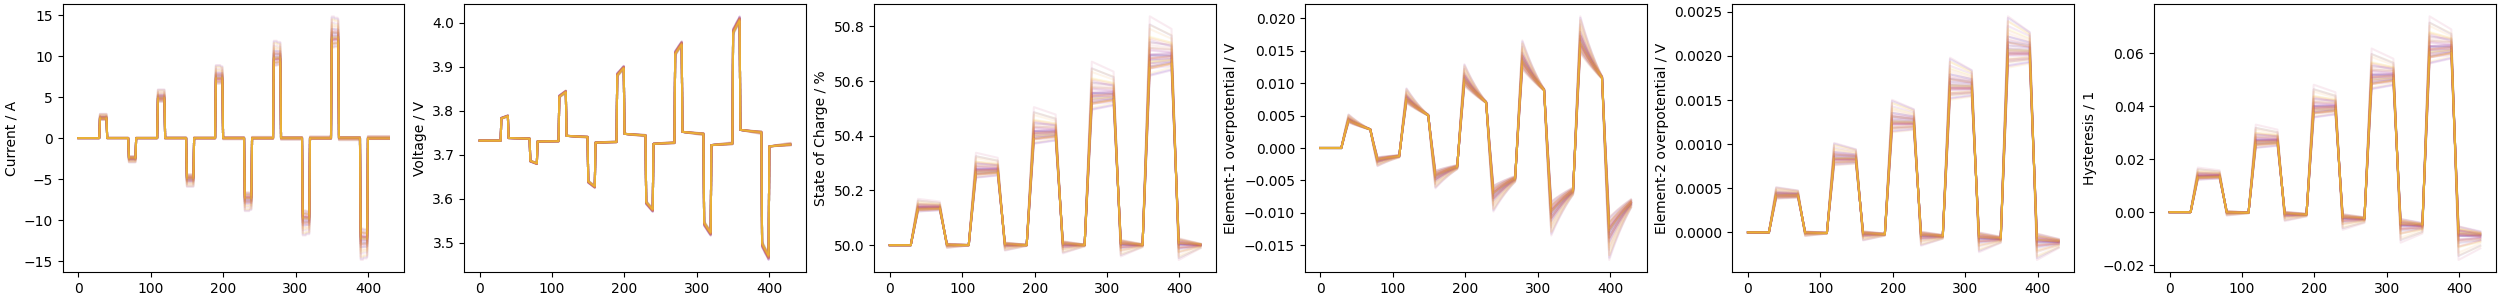

In [6]:
cmap = plt.colormaps["plasma"]
alpha = 0.1
fig, axs = plt.subplots(1, 6, figsize=(25, 3), constrained_layout=True)
for i, name in enumerate(
    [
        "Current / A",
        "Voltage / V",
        "State of Charge / %",
        "Element-1 overpotential / V",
        "Element-2 overpotential / V",
        "Hysteresis / 1",
    ]
):
    axs[i].set_ylabel(name)

n = module.n_series * module.n_parallel
m = 0
for i in range(module.n_series):
    for j in range(module.n_parallel):
        color = cmap(m / (n - 1))
        axs[0].plot(sim.t, sim.cell_current[:, i, j], color=color, alpha=alpha)
        axs[1].plot(sim.t, sim.cell_voltage[:, i, j], color=color, alpha=alpha)
        axs[2].plot(sim.t, 100 * sim.cell_soc[:, i, j], color=color, alpha=alpha)
        axs[3].plot(sim.t, sim.cell_polarization[0][:, i, j], color=color, alpha=alpha)
        axs[4].plot(sim.t, sim.cell_polarization[1][:, i, j], color=color, alpha=alpha)
        axs[5].plot(sim.t, sim.cell_hysteresis[:, i, j], color=color, alpha=alpha)
        m += 1

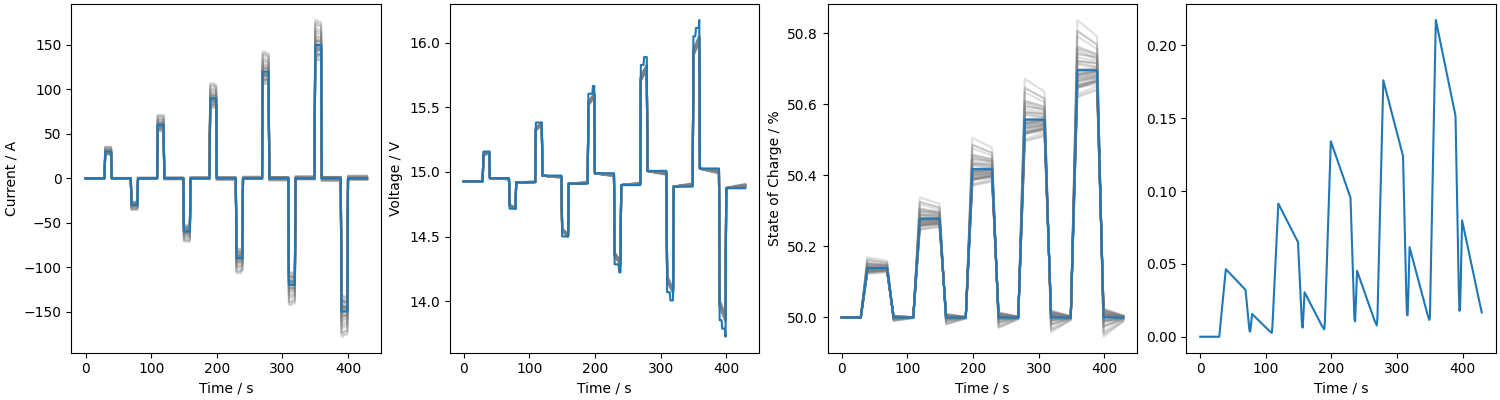

In [7]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4), constrained_layout=True)
axs[0].set_ylabel("Current / A")
axs[1].set_ylabel("Voltage / V")
axs[2].set_ylabel("State of Charge / %")
for ax in axs:
    ax.set_xlabel("Time / s")

axs[0].plot(sim.t, sim.module_current)
axs[0].plot(
    sim.t,
    module.n_parallel * sim.cell_current.reshape((sim.t.size, -1)),
    color="gray",
    alpha=0.25,
    zorder=-1,
)

axs[1].plot(sim.t, sim.module_voltage)
axs[1].plot(
    sim.t,
    module.n_series * sim.cell_voltage.reshape((sim.t.size, -1)),
    color="gray",
    alpha=0.25,
    zorder=-1,
)


axs[2].plot(sim.t, 100 * sim.module_soc)
axs[2].plot(
    sim.t,
    100 * sim.cell_soc.reshape((sim.t.size, -1)),
    color="gray",
    alpha=0.25,
    zorder=-1,
)
axs[3].plot(sim.t, 100 * sim.cell_imbalance)